# 03 - FaceNet512 Regularized Training

Khắc phục overfitting ở FaceNet512 bằng:
- **K-Fold Cross-Validation** (5-fold) cho kết quả đáng tin cậy
- **Stronger regularization**: L2=5e-4, Dropout tăng
- **Simpler MLP**: giảm capacity (512→256→128→1)
- **So sánh trực tiếp** train-test gap

Kết quả lưu tại `logs/my_logs/Facenet512_*_regularized/`

In [1]:
import os, pickle, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)

TensorFlow: 2.20.0
Keras: 3.12.0


In [2]:
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))
if not os.path.exists(os.path.join(PROJECT_ROOT, 'notebooks')):
    PROJECT_ROOT = os.getcwd()

PKL_DIR     = os.path.join(PROJECT_ROOT, 'models', 'precomputed')
DATASET_DIR = os.path.join(PROJECT_ROOT, 'data', 'raw', 'lfw_funneled')
PAIRS_FILE  = os.path.join(DATASET_DIR, 'pairs.txt')
OUTPUT_DIR  = os.path.join(PROJECT_ROOT, 'logs', 'my_logs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)

PROJECT_ROOT: x:\sv3_hk2\graduation_thesis\facenet


In [3]:
def load_pairs(pf, dd):
    pairs = []
    with open(pf) as f: lines = f.read().strip().splitlines()
    nf, np_ = int(lines[0].split()[0]), int(lines[0].split()[1])
    idx = 1
    for _ in range(nf):
        for _ in range(np_):
            p = lines[idx].split(); idx += 1
            nm,i,j = p[0],int(p[1]),int(p[2])
            p1=os.path.join(dd,nm,f'{nm}_{i:04d}.jpg')
            p2=os.path.join(dd,nm,f'{nm}_{j:04d}.jpg')
            if os.path.exists(p1) and os.path.exists(p2): pairs.append((p1,p2,1))
        for _ in range(np_):
            p = lines[idx].split(); idx += 1
            n1,i,n2,j = p[0],int(p[1]),p[2],int(p[3])
            p1=os.path.join(dd,n1,f'{n1}_{i:04d}.jpg')
            p2=os.path.join(dd,n2,f'{n2}_{j:04d}.jpg')
            if os.path.exists(p1) and os.path.exists(p2): pairs.append((p1,p2,0))
    print(f'{len(pairs)} pairs (same={sum(l==1 for _,_,l in pairs)}, diff={sum(l==0 for _,_,l in pairs)})')
    return pairs

def load_pkl_remap(pkl_path, new_base):
    with open(pkl_path,'rb') as f: raw = pickle.load(f)
    remapped = {}
    for k, v in raw.items():
        k_norm = k.replace("\\", "/")
        if "lfw_funneled/" in k_norm:
            rel = k_norm.split("lfw_funneled/",1)[1]
            new_key = os.path.normpath(os.path.join(new_base, rel))
        else:
            new_key = k
        remapped[new_key] = np.array(v)
    print(f'Loaded {len(remapped)} from {os.path.basename(pkl_path)}')
    return remapped

def build_features_concat(pairs, emb_dict):
    X, y = [], []
    for p1,p2,lbl in pairs:
        e1,e2 = emb_dict.get(p1), emb_dict.get(p2)
        if e1 is None or e2 is None: continue
        if np.sum(e1)==0 or np.sum(e2)==0: continue
        X.append(np.concatenate([np.abs(e1-e2), e1*e2])); y.append(lbl)
    return np.array(X), np.array(y)

In [4]:
# ---- MLP Architectures with Stronger Regularization ----

def build_mlp_reg1(dim):
    """512->256->128->1, L2=5e-4, higher dropout."""
    m = keras.Sequential([
        layers.Input(shape=(dim,)),
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(5e-4)),
        layers.BatchNormalization(), layers.Dropout(0.5),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(5e-4)),
        layers.BatchNormalization(), layers.Dropout(0.4),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(5e-4)),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=keras.optimizers.Adam(3e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_mlp_reg2(dim):
    """256->128->64->1, stronger L2=1e-3."""
    m = keras.Sequential([
        layers.Input(shape=(dim,)),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-3)),
        layers.BatchNormalization(), layers.Dropout(0.5),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-3)),
        layers.BatchNormalization(), layers.Dropout(0.4),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-3)),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=keras.optimizers.Adam(3e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_mlp_reg3(dim):
    """768->384->128->1, balanced."""
    m = keras.Sequential([
        layers.Input(shape=(dim,)),
        layers.Dense(768, activation='relu', kernel_regularizer=regularizers.l2(5e-4)),
        layers.BatchNormalization(), layers.Dropout(0.5),
        layers.Dense(384, activation='relu', kernel_regularizer=regularizers.l2(5e-4)),
        layers.BatchNormalization(), layers.Dropout(0.4),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(5e-4)),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=keras.optimizers.Adam(3e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return m

MLP_CONFIGS = [
    ('Reg1_512x256x128', build_mlp_reg1),
    ('Reg2_256x128x64', build_mlp_reg2),
    ('Reg3_768x384x128', build_mlp_reg3),
]

In [5]:
def compute_eer(yt, ys):
    ths=np.linspace(0,1,500); fl,rl=[],[]
    for t in ths:
        yp=(ys>=t).astype(int)
        fp=np.sum((yp==1)&(yt==0)); tn=np.sum((yp==0)&(yt==0))
        fn=np.sum((yp==0)&(yt==1)); tp=np.sum((yp==1)&(yt==1))
        fl.append(fp/(fp+tn+1e-9)); rl.append(fn/(fn+tp+1e-9))
    far,frr=np.array(fl),np.array(rl)
    idx=np.argmin(np.abs(far-frr))
    return (far[idx]+frr[idx])/2, ths[idx]

def plot_confusion_matrix(y_true, y_pred, classes, output_path):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred)
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest')
    plt.title('Confusion Matrix', fontsize=13)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center",
                     color="white" if cm[i,j] > cm.max()/2 else "black",
                     fontsize=10, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f"{output_path}/confusion_matrix.png", dpi=150)
    plt.show()
    plt.close()

In [6]:
pairs = load_pairs(PAIRS_FILE, DATASET_DIR)
print('Ready!')

5996 pairs (same=2998, diff=2998)
Ready!


---
## 5-Fold Cross-Validation + Regularized Training
So sánh regularization strategies trên cả 2 detectors.

In [7]:
EPOCHS = 24
N_FOLDS = 5

DETECTORS = [
    ('mtcnn', 'Facenet512_mtcnn_embeddings.pkl'),
    ('retinaface', 'Facenet512_retinaface_embeddings.pkl'),
]

all_cv_results = []
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

for detector, pkl_file in DETECTORS:
    pkl_path = os.path.join(PKL_DIR, pkl_file)
    emb_dict = load_pkl_remap(pkl_path, DATASET_DIR)
    X, y = build_features_concat(pairs, emb_dict)
    print(f'{detector}: X={X.shape}')

    for mlp_name, build_mlp_fn in MLP_CONFIGS:
        tag = f'Facenet512_{detector}_{mlp_name}'
        od  = os.path.join(OUTPUT_DIR, tag)
        os.makedirs(od, exist_ok=True)
        print(f'\n{"="*55}\n {tag}\n{"="*55}')

        fold_metrics = []
        fold = 1
        for train_idx, val_idx in skf.split(X, y):
            print(f'\n--- Fold {fold}/{N_FOLDS} ---')
            Xtr_f, Xval_f = X[train_idx], X[val_idx]
            ytr_f, yval_f = y[train_idx], y[val_idx]

            mlp = build_mlp_fn(Xtr_f.shape[1])
            callbacks = [
                keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
                keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0)
            ]
            hist = mlp.fit(Xtr_f, ytr_f, epochs=EPOCHS, batch_size=64,
                          validation_data=(Xval_f, yval_f), callbacks=callbacks, verbose=0)

            ys = mlp.predict(Xval_f, verbose=0).flatten()
            yp = (ys >= 0.5).astype(int)
            tea = np.mean(yp == yval_f)
            tra_hist = hist.history['accuracy'][-1]
            val_loss_hist = hist.history['val_loss'][-1]
            prec = precision_score(yval_f, yp, zero_division=0)
            rec = recall_score(yval_f, yp, zero_division=0)
            f1v = f1_score(yval_f, yp, zero_division=0)
            eer, _ = compute_eer(yval_f, ys)

            fold_metrics.append({
                'fold': fold, 'train_acc': round(tra_hist, 4),
                'val_acc': round(tea, 4), 'val_loss': round(val_loss_hist, 4),
                'precision': round(prec, 4), 'recall': round(rec, 4),
                'f1': round(f1v, 4), 'eer': round(eer, 4)
            })
            print(f'  Fold {fold}: val_acc={tea:.4f}, f1={f1v:.4f}, eer={eer:.4f}, gap={tra_hist-tea:.4f}')
            fold += 1
            tf.keras.backend.clear_session()

        # Aggregate CV results
        df_fold = pd.DataFrame(fold_metrics)
        avg = {k: df_fold[k].mean() for k in ['train_acc','val_acc','precision','recall','f1','eer']}
        std = {k: df_fold[k].std() for k in ['val_acc','f1','eer']}

        summary = {
            'model': tag,
            'train_acc': round(avg['train_acc'], 4),
            'test_acc': round(avg['val_acc'], 4),
            'val_acc_std': round(std['val_acc'], 4),
            'precision': round(avg['precision'], 4),
            'recall': round(avg['recall'], 4),
            'f1': round(avg['f1'], 4),
            'f1_std': round(std['f1'], 4),
            'eer': round(avg['eer'], 4),
            'eer_std': round(std['eer'], 4),
            'gap_train_test': round(avg['train_acc'] - avg['val_acc'], 4),
        }
        all_cv_results.append(summary)

        # Save fold details
        df_fold.to_csv(os.path.join(od, 'cv_folds.csv'), index=False)
        print(f'\nAvg: val_acc={avg["val_acc"]:.4f} ± {std["val_acc"]:.4f}, f1={avg["f1"]:.4f}, eer={avg["eer"]:.4f}, gap={summary["gap_train_test"]:.4f}')

Loaded 7701 from Facenet512_mtcnn_embeddings.pkl
mtcnn: X=(5996, 1024)

 Facenet512_mtcnn_Reg1_512x256x128

--- Fold 1/5 ---
  Fold 1: val_acc=0.9483, f1=0.9468, eer=0.0667, gap=0.0456


--- Fold 2/5 ---
  Fold 2: val_acc=0.9550, f1=0.9542, eer=0.0542, gap=0.0407

--- Fold 3/5 ---
  Fold 3: val_acc=0.9616, f1=0.9611, eer=0.0400, gap=0.0298

--- Fold 4/5 ---
  Fold 4: val_acc=0.9450, f1=0.9433, eer=0.0651, gap=0.0430

--- Fold 5/5 ---
  Fold 5: val_acc=0.9374, f1=0.9374, eer=0.0617, gap=0.0580

Avg: val_acc=0.9495 ± 0.0093, f1=0.9486, eer=0.0575, gap=0.0434

 Facenet512_mtcnn_Reg2_256x128x64

--- Fold 1/5 ---
  Fold 1: val_acc=0.9292, f1=0.9288, eer=0.0733, gap=0.0569

--- Fold 2/5 ---
  Fold 2: val_acc=0.9500, f1=0.9494, eer=0.0542, gap=0.0348

--- Fold 3/5 ---
  Fold 3: val_acc=0.9625, f1=0.9623, eer=0.0434, gap=0.0231

--- Fold 4/5 ---
  Fold 4: val_acc=0.9374, f1=0.9365, eer=0.0601, gap=0.0486

--- Fold 5/5 ---
  Fold 5: val_acc=0.9450, f1=0.9433, eer=0.0584, gap=0.0407

Avg: val_ac

In [8]:
df_cv = pd.DataFrame(all_cv_results)
df_cv = df_cv.sort_values('test_acc', ascending=False)
print('\n========== 5-FOLD CV RESULTS (sorted by test_acc) ==========')
print(df_cv.to_string(index=False))

csv_path = os.path.join(OUTPUT_DIR, 'MLP_Facenet512_Regularized_CV.csv')
df_cv.to_csv(csv_path, index=False)
print(f'\nSaved to: {csv_path}')


========== 5-FOLD CV RESULTS (sorted by test_acc) ==========
                                 model  train_acc  test_acc  val_acc_std  precision  recall     f1  f1_std    eer  eer_std  gap_train_test
Facenet512_retinaface_Reg1_512x256x128     0.9947    0.9642       0.0035     0.9759  0.9520 0.9637  0.0034 0.0399   0.0032          0.0306
Facenet512_retinaface_Reg3_768x384x128     0.9955    0.9625       0.0028     0.9729  0.9516 0.9621  0.0029 0.0384   0.0031          0.0330
 Facenet512_retinaface_Reg2_256x128x64     0.9906    0.9601       0.0064     0.9656  0.9543 0.9599  0.0064 0.0424   0.0069          0.0305
     Facenet512_mtcnn_Reg1_512x256x128     0.9929    0.9495       0.0093     0.9664  0.9316 0.9486  0.0093 0.0575   0.0109          0.0434
     Facenet512_mtcnn_Reg3_768x384x128     0.9948    0.9488       0.0068     0.9619  0.9346 0.9481  0.0071 0.0552   0.0097          0.0460
      Facenet512_mtcnn_Reg2_256x128x64     0.9856    0.9448       0.0126     0.9570  0.9316 0.9441  0.01

In [10]:
print('\n=== BEST MODEL PER METRIC ===')
for metric in ['test_acc', 'f1']:
    best = df_cv.loc[df_cv[metric].idxmax()]
    std_col = 'val_acc_std' if metric == 'test_acc' else f'{metric}_std'
    print(f'{metric}: {best["model"]} ({best[metric]:.4f} ± {best[std_col]:.4f})')
for metric in ['eer', 'gap_train_test']:
    best = df_cv.loc[df_cv[metric].idxmin()]
    print(f'{metric} (lower): {best["model"]} ({best[metric]:.4f})')

print('\n=== OVERFITTING GAP ANALYSIS ===')
print('Model with smallest train-test gap (least overfit):')
best_gap = df_cv.loc[df_cv['gap_train_test'].idxmin()]
print(f'  {best_gap["model"]} (gap={best_gap["gap_train_test"]:.4f})')
print('Model with largest gap (most overfit):')
worst_gap = df_cv.loc[df_cv['gap_train_test'].idxmax()]
print(f'  {worst_gap["model"]} (gap={worst_gap["gap_train_test"]:.4f})')


=== BEST MODEL PER METRIC ===
test_acc: Facenet512_retinaface_Reg1_512x256x128 (0.9642 ± 0.0035)
f1: Facenet512_retinaface_Reg1_512x256x128 (0.9637 ± 0.0034)
eer (lower): Facenet512_retinaface_Reg3_768x384x128 (0.0384)
gap_train_test (lower): Facenet512_retinaface_Reg2_256x128x64 (0.0305)

=== OVERFITTING GAP ANALYSIS ===
Model with smallest train-test gap (least overfit):
  Facenet512_retinaface_Reg2_256x128x64 (gap=0.0305)
Model with largest gap (most overfit):
  Facenet512_mtcnn_Reg3_768x384x128 (gap=0.0460)


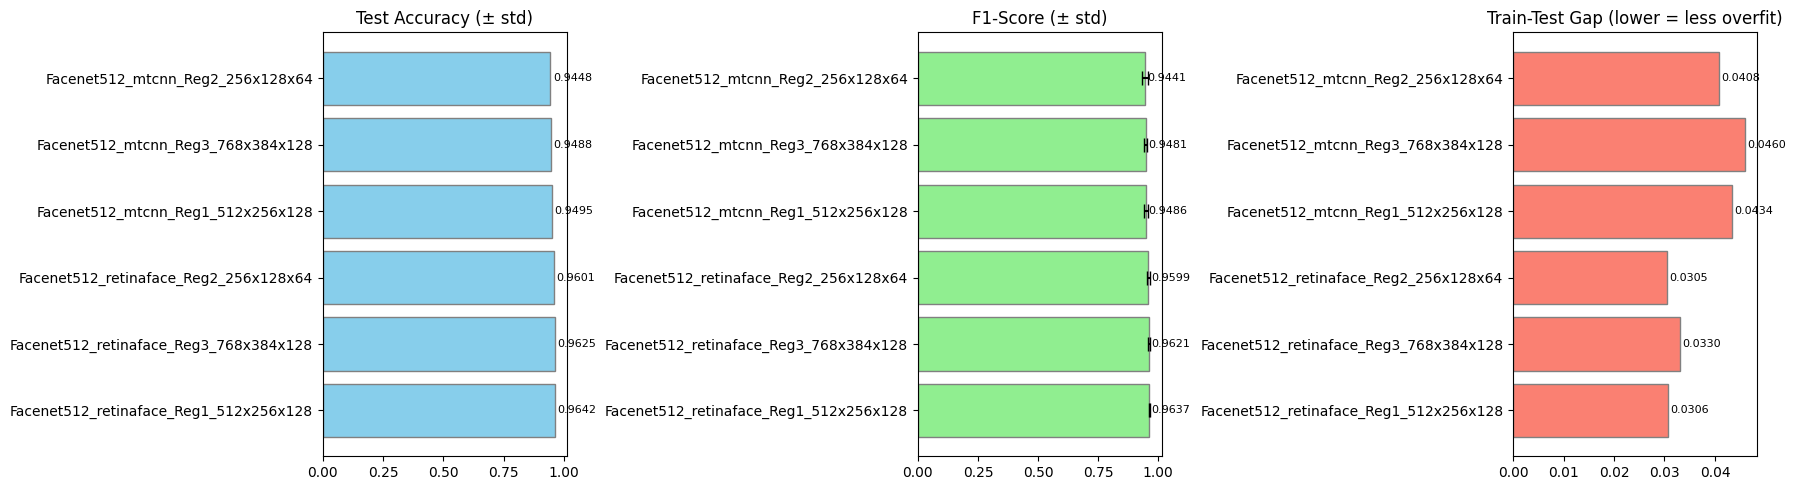

Done!


In [11]:
# Plot: Gap analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, title, color in zip(axes,
    ['test_acc', 'f1', 'gap_train_test'],
    ['Test Accuracy (± std)', 'F1-Score (± std)', 'Train-Test Gap (lower = less overfit)'],
    ['skyblue', 'lightgreen', 'salmon']):

    vals = df_cv[metric]
    err = df_cv[f'{metric}_std'] if f'{metric}_std' in df_cv.columns else None
    bars = ax.barh(df_cv['model'], vals, xerr=err, color=color, edgecolor='gray', capsize=5)
    ax.set_title(title, fontsize=12)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() + max(vals)*0.01, bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'comparison_facenet512_regularized.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Done!')

---
## Full Training on Best Configurations
Train top-2 configs on full data (80/20 split) + save predictions.

In [12]:
# Pick top configs for each detector (by test_acc)
best_configs = []
for detector in ['mtcnn', 'retinaface']:
    sub = df_cv[df_cv['model'].str.contains(detector)]
    if len(sub) == 0: continue
    best_row = sub.loc[sub['test_acc'].idxmax()]
    # Find which MLP config it matches
    mlp_name = best_row['model'].replace(f'Facenet512_{detector}_', '')
    for name, fn in MLP_CONFIGS:
        if name == mlp_name:
            pkl_file = f'Facenet512_{detector}_embeddings.pkl'
            best_configs.append((detector, pkl_file, name, fn))
            break

print('Best configs for full training:')
for det, pkl, name, fn in best_configs:
    print(f'  {det}: {name}')

Best configs for full training:
  mtcnn: Reg1_512x256x128
  retinaface: Reg1_512x256x128



 FULL TRAIN: Facenet512_mtcnn_Reg1_512x256x128_regularized
Loaded 7701 from Facenet512_mtcnn_embeddings.pkl
Features: (5996, 1024)
Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8805 - loss: 0.8991 - val_accuracy: 0.9097 - val_loss: 0.9021 - learning_rate: 3.0000e-04
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9335 - loss: 0.7902 - val_accuracy: 0.9250 - val_loss: 0.8602 - learning_rate: 3.0000e-04
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9404 - loss: 0.7570 - val_accuracy: 0.9292 - val_loss: 0.8108 - learning_rate: 3.0000e-04
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9455 - loss: 0.7325 - val_accuracy: 0.9333 - val_loss: 0.7783 - learning_rate: 3.0000e-04
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9526 - loss: 0.7039 - val_accuracy: 0.9389 - val_loss: 0.7578 - learning_rate: 3.0000e-04
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9549 - loss: 0.6810 - val_ac

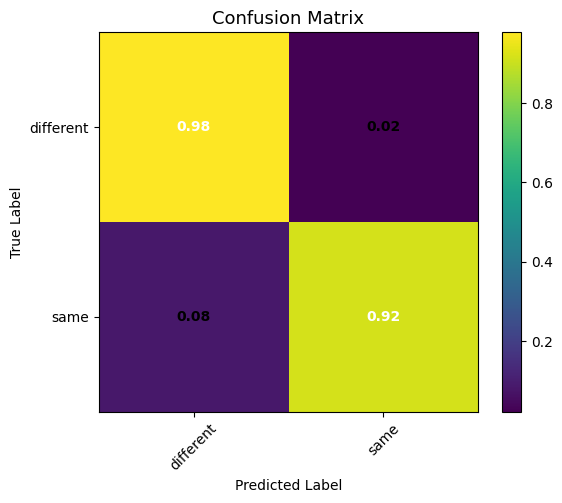

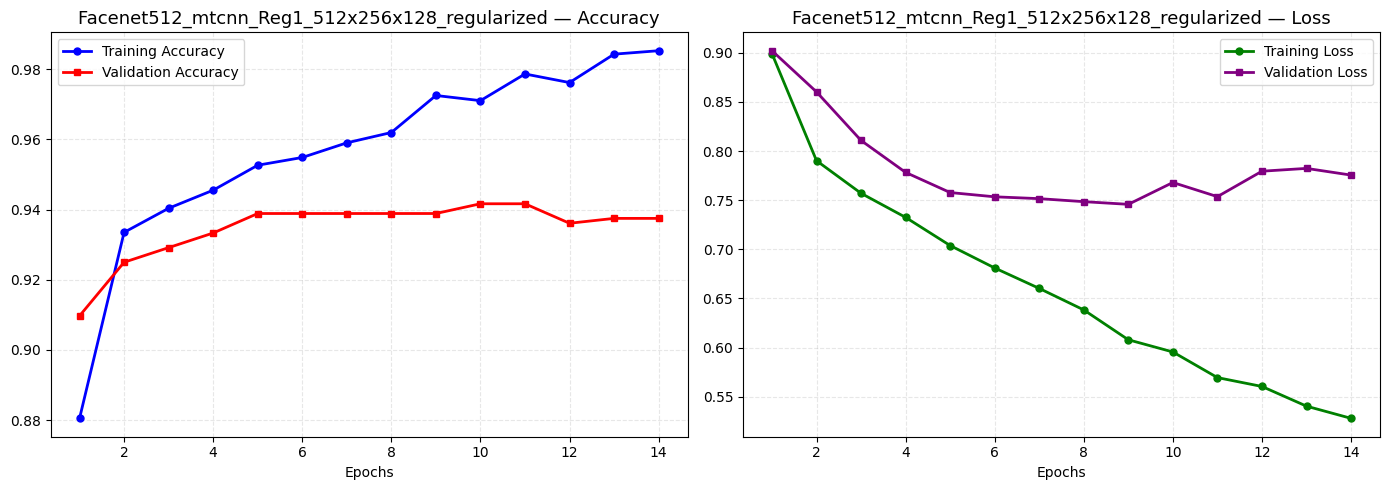


 FULL TRAIN: Facenet512_retinaface_Reg1_512x256x128_regularized
Loaded 7701 from Facenet512_retinaface_embeddings.pkl
Features: (5996, 1024)
Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8741 - loss: 0.8896 - val_accuracy: 0.9292 - val_loss: 0.8646 - learning_rate: 3.0000e-04
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9585 - loss: 0.7245 - val_accuracy: 0.9444 - val_loss: 0.8105 - learning_rate: 3.0000e-04
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9627 - loss: 0.6992 - val_accuracy: 0.9569 - val_loss: 0.7635 - learning_rate: 3.0000e-04
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9669 - loss: 0.6744 - val_accuracy: 0.9583 - val_loss: 0.7473 - learning_rate: 3.0000e-04
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9674 - loss: 0.6587 - val_accuracy: 0.9583 - val_loss: 0.7343 - learning_rate: 3.0000e-04
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9718 - loss: 0.634

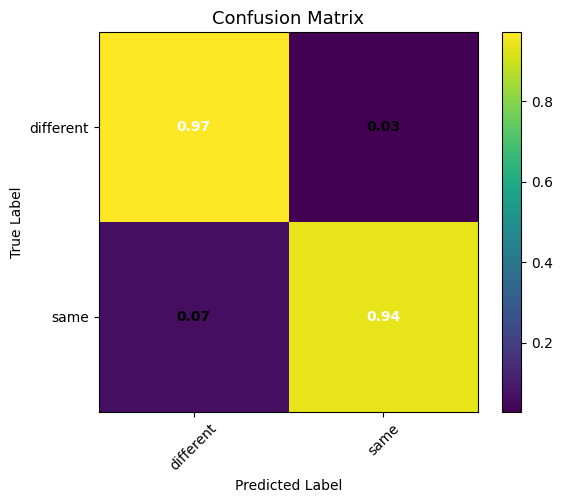

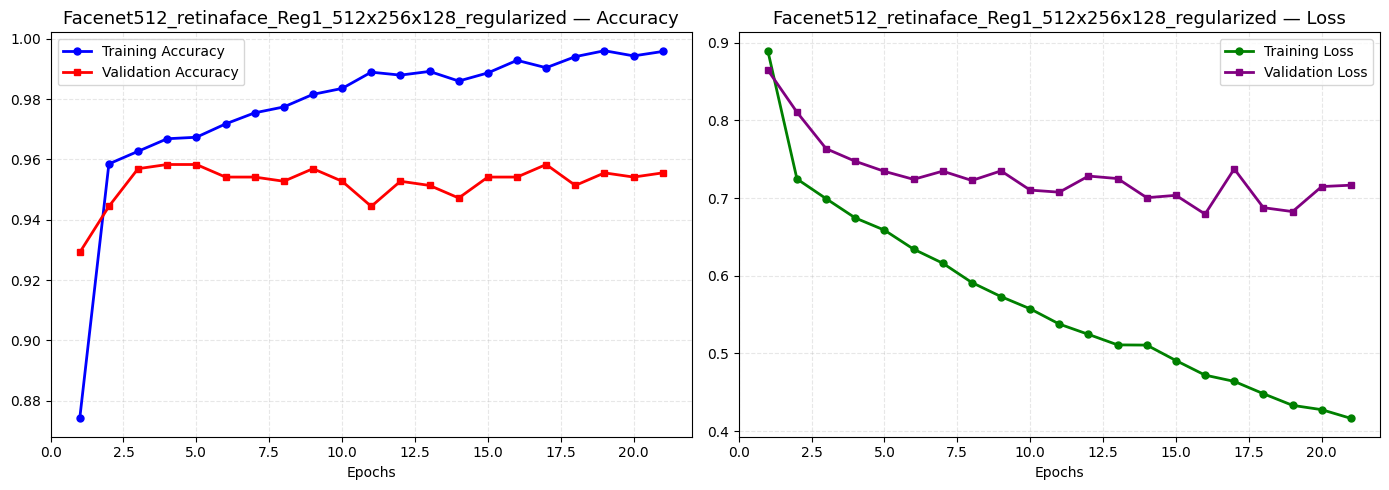

In [13]:
EPOCHS_FULL = 30

for detector, pkl_file, mlp_name, build_mlp_fn in best_configs:
    tag = f'Facenet512_{detector}_{mlp_name}_regularized'
    od  = os.path.join(OUTPUT_DIR, tag)
    os.makedirs(od, exist_ok=True)
    pkl_path = os.path.join(PKL_DIR, pkl_file)

    print(f'\n{"="*60}\n FULL TRAIN: {tag}\n{"="*60}')

    emb_dict = load_pkl_remap(pkl_path, DATASET_DIR)
    X, y = build_features_concat(pairs, emb_dict)
    print(f'Features: {X.shape}')
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    mlp = build_mlp_fn(Xtr.shape[1])
    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
    ]
    hist = mlp.fit(Xtr, ytr, epochs=EPOCHS_FULL, batch_size=64,
                   validation_split=0.15, callbacks=callbacks, verbose=1)

    t0 = time.time(); ys = mlp.predict(Xte, verbose=0).flatten(); tit = time.time() - t0
    yp = (ys >= 0.5).astype(int)
    trl, tra = mlp.evaluate(Xtr, ytr, verbose=0)
    tel, tea = mlp.evaluate(Xte, yte, verbose=0)
    prec = precision_score(yte, yp, zero_division=0)
    rec = recall_score(yte, yp, zero_division=0)
    f1v = f1_score(yte, yp, zero_division=0)
    eer, eer_t = compute_eer(yte, ys)
    infer_avg_s = tit / len(Xte)

    # Save report
    rpt = f"--- BAO CAO KET QUA NHAN DIEN (REGULARIZED) ---\nModel: {tag} | Detector: {detector}\n"
    rpt += f"EER: {eer:.4f} @ Threshold: {eer_t:.4f}\nTrain Acc: {tra:.4f}\nTest Acc: {tea:.4f}\n"
    rpt += f"Train Loss: {trl:.4f}\nTest Loss: {tel:.4f}\nPrecision: {prec:.4f}\nRecall: {rec:.4f}\nF1: {f1v:.4f}\n"
    rpt += f"Overfit gap: {tra - tea:.4f}\nTB predict/anh: {infer_avg_s:.6f}s\n"
    print(rpt)
    with open(os.path.join(od, 'final_report.txt'), 'w', encoding='utf-8') as f: f.write(rpt)

    # Save classification report
    creport = classification_report(yte, yp, target_names=['different', 'same'], zero_division=0)
    with open(os.path.join(od, 'classification_report.txt'), 'w') as f: f.write(creport)

    # Plot confusion matrix
    plot_confusion_matrix(yte, yp, classes=['different', 'same'], output_path=od)

    # Plot training curves
    epochs_r = range(1, len(hist.history['accuracy']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (m, title), (c1, c2) in zip(axes,
        [('accuracy', 'Accuracy'), ('loss', 'Loss')],
        [('blue', 'red'), ('green', 'purple')]):
        train_v = hist.history[m]
        val_v = hist.history[f'val_{m}']
        ax.plot(epochs_r, train_v, 'o-', color=c1, label=f'Training {title}', linewidth=2, markersize=5)
        ax.plot(epochs_r, val_v, 's-', color=c2, label=f'Validation {title}', linewidth=2, markersize=5)
        ax.set_title(f'{tag} — {title}', fontsize=13)
        ax.set_xlabel('Epochs')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(od, 'training_curves.png'), dpi=150)
    plt.show()
    plt.close()

    tf.keras.backend.clear_session()

In [14]:
import glob
regularized_dirs = [d for d in os.listdir(OUTPUT_DIR) if 'regularized' in d]
print('Regularized model results saved in:')
for d in sorted(regularized_dirs):
    report_path = os.path.join(OUTPUT_DIR, d, 'final_report.txt')
    if os.path.exists(report_path):
        with open(report_path) as f:
            first_lines = ''.join(f.readlines()[:6])
        print(f'\n--- {d} ---')
        print(first_lines.strip())

print(f'\nAll results saved to: {OUTPUT_DIR}')
print('Done!')

Regularized model results saved in:

--- Facenet512_mtcnn_Reg1_512x256x128_regularized ---
--- BAO CAO KET QUA NHAN DIEN (REGULARIZED) ---
Model: Facenet512_mtcnn_Reg1_512x256x128_regularized | Detector: mtcnn
EER: 0.0633 @ Threshold: 0.1864
Train Acc: 0.9821
Test Acc: 0.9483
Train Loss: 0.5830

--- Facenet512_retinaface_Reg1_512x256x128_regularized ---
--- BAO CAO KET QUA NHAN DIEN (REGULARIZED) ---
Model: Facenet512_retinaface_Reg1_512x256x128_regularized | Detector: retinaface
EER: 0.0533 @ Threshold: 0.1804
Train Acc: 0.9929
Test Acc: 0.9533
Train Loss: 0.4831

All results saved to: x:\sv3_hk2\graduation_thesis\facenet\logs\my_logs
Done!
